In [186]:
from pyod.utils.data import generate_data
from matplotlib import pyplot as plt

(400, 2) (100, 2) (400,) (100,)


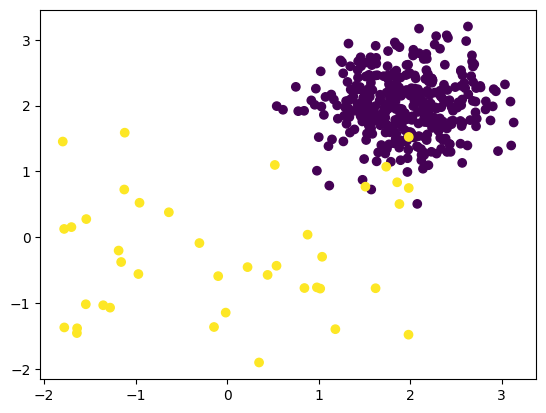

In [212]:
# ex 1

'''
Use the generate data() function from pyod.utils.data to generate a 2-
dimensional dataset with 500 normal samples (400 training samples and 100
test samples) with a contamination rate of 0.1.
'''
X_train, X_test, y_train, y_test = generate_data(n_features=2, n_train=400, n_test=100, contamination=0.1)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
"""
Use pyplot.scatter() function to plot the training samples, choosing a dif-
ferent color for the outliers.
"""

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

In [213]:
# ex 2
from pyod.models.knn import KNN

"""
Choose a model from pyod (ex: KNN), leave all the parameters default (ex-
cept the contamination, which will match the contamination used for dataset
generation) and fit it with the training data. Get the predictions of the model
for both the training and the testing data.
"""
model = KNN(contamination=0.1)
model.fit(X_train)

preds = model.predict(X_test)
scores = model.decision_function(X_test)
print(scores.shape)

(100,)


0.9444444444444444


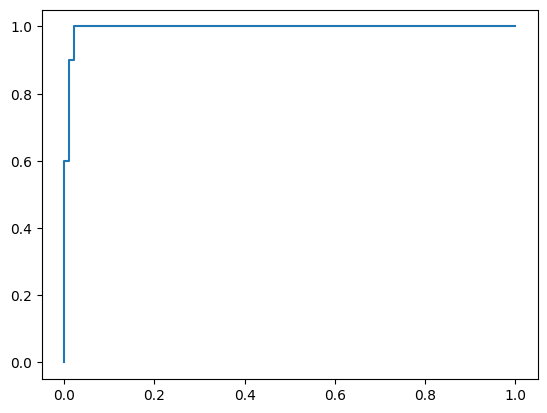

In [215]:
from sklearn.metrics import confusion_matrix, roc_curve

"""
Use the confusion matrix function from sklearn.metrics to find the
number of TN, TP, FN and FP and compute the balanced accuracy.
Use the roc curve() function from sklearn.metrics to compute the ROC
curve and then plot it with plot() function.
"""

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)
tnr = tn / (tn + fp)

ba = (tpr + tnr) / 2
fpr = fp / (fp + tn)
print(ba)

fpr, tpr, _ = roc_curve(y_test, scores)
plt.plot(fpr, tpr)

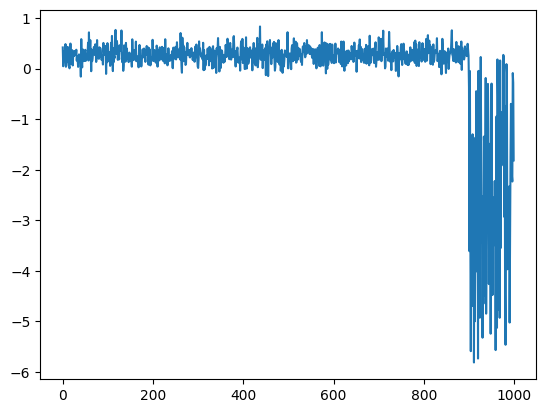

In [ ]:
# ex 3
"""Generate a unidimensional dataset with 10 % contamination rate, 1000 train-
ing samples and no testing samples using generate data()."""
X_train, X_test, y_train, y_test = generate_data(n_features=1, n_train=1000, n_test=0, contamination=0.1)

import numpy as np
z_scores = (X_train - np.mean(X_train)) / np.std(X_train)
plt.plot(z_scores)

"""Try to detect the
anomalies in the dataset by using the Z-scores. 
In order to do that you should
compute the Z-score threshold that would classify the given percent (contami-
nation rate) of data as anomalies (use np.quantile() function)
"""
threshold = np.quantile(np.abs(z_scores), 0.9)
anomalies = np.abs(z_scores) > threshold
anomalies = anomalies.ravel()

""" Compute the
balanced accuracy of the designed method."""
from sklearn.metrics import balanced_accuracy_score

bac = balanced_accuracy_score(y_train, anomalies)

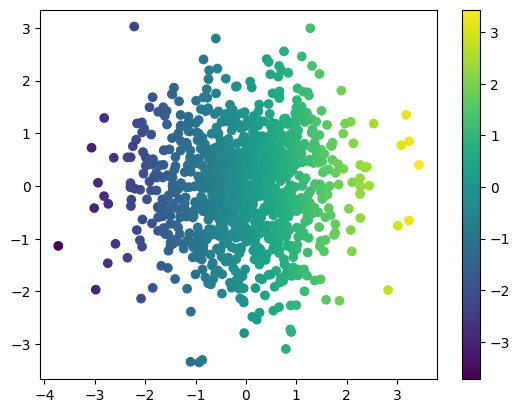

In [225]:
# ex 4
"""
Same as Ex. 3 but for a multidimensional dataset. Choose your own mean
vector µ and covariance matrix Σ and build your dataset by hand starting with
the samples generated from a multivariate standard normal distribution, x ∼
N (0, I). 
"""
x = np.random.multivariate_normal(mean=np.array([0, 0]), cov=np.identity(2), size=1000)

plt.scatter(x[:, 0], x[:, 1], c=x[:, 0])
plt.colorbar()

[[2.  1.9]
 [1.9 2. ]]


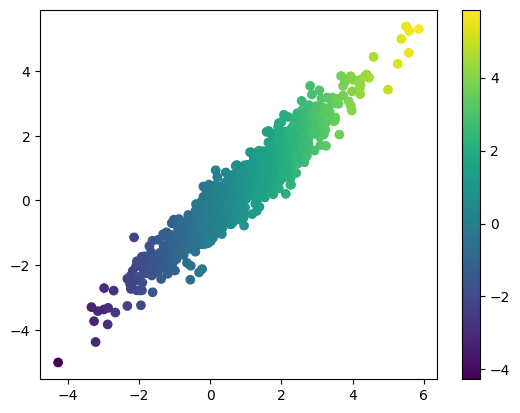

In [226]:
"""
Using the Cholesky decomposition of the covariance matrix Σ = LLT
draw your samples y like this: y = Lx + µ and then compute the Z-scores.
"""
mu = np.array([1, 0.5])
cov = 1.9
variance = 2
cov_matrix = np.array([[variance, cov],
                [cov, variance]])

L = np.linalg.cholesky(cov_matrix)

print(L @ L.T)
y = (L @ x.T).T + [1, 0.5]
plt.scatter(y[:, 0], y[:, 1], c=y[:, 0])
plt.colorbar()


(1000,)
(1000, 2)
(1000,)
(1000,)


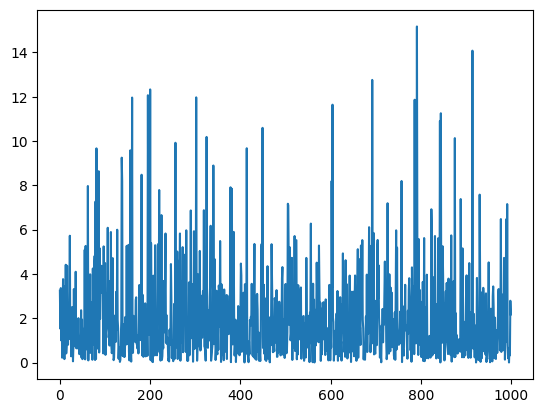

In [235]:
"""
compute the Z-scores. All
other tasks as in Ex. 3."""
z_scores = np.array([
    (yi - mu).T @ np.linalg.inv(cov_matrix) @ (yi - mu)
    for yi in y
])
print(z_scores.shape)
threshold = np.quantile(np.abs(z_scores), 0.9)
anomalies = np.abs(z_scores) > threshold
print(y.shape)
print(z_scores.shape)
print(anomalies.shape)
plt.plot(z_scores)